In [24]:
# importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [25]:
print(pd.__version__)
print(np.__version__)

3.0.5
2.5.3


Mounted at /content/drive


In [4]:
# Load the cleaned dataset from Google Drive
df=pd.read_csv('C:\Machine Learning Projects\Food Delivery Time Prediction\Data Sets\cleaned_dataset (1).csv')

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\venum\AppData\Local\Temp\ipykernel_2604\2165746842.py:2: SyntaxWarning: invalid escape sequence '\M'
  df=pd.read_csv('C:\Machine Learning Projects\Food Delivery Time Prediction\Data Sets\cleaned_dataset (1).csv')


In [5]:
# Display the first few rows of the dataset
df.head()

,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.1,3.8,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.8,3.6,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.8,3.9,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.7,3.9,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.4,4.4,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [6]:
# Selecting Dependent and Independent Variables
X = df.drop(["Time_taken_min",'Average_Speed_kmph'], axis=1)
y = df["Time_taken_min"]

In [7]:
# Split the data into training and testing parts
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
# Seperation of numerical and categorical Features
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

print("Numerical:", list(num_cols))
print("Categorical:", list(cat_cols))

Numerical: ['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating', 'Order_Items', 'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals']
Categorical: ['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load', 'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority']


C:\Users\venum\AppData\Local\Temp\ipykernel_2604\4160198608.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns


In [9]:
# Define nominal and ordinal feature groups for encoding
nominal_col=['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type']
ordinal_col=['Restaurant_Load','Delivery_Distance_Category','Traffic_Level', 'Delivery_Priority']

In [10]:
# Pipeline for numerical features (imputation and scaling)
num_pipeline=Pipeline([
        ('imputer',SimpleImputer(strategy='mean')),
        ('scalar',StandardScaler())
    ])

In [11]:
# Pipeline for numerical features (imputation and scaling)
nominal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scalar',OneHotEncoder(handle_unknown='ignore'))
])

In [12]:
# Pipeline for ordinal categorical features (imputation and ordinal encoding)
ordinal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scalar',OrdinalEncoder(
        categories=[
            ["Low", "Medium", "High"],
            ["Short", "Medium", "Long"],
            ["Low", "Moderate", "High", "Severe"],
            ["Normal", "Priority", "VIP"]
        ])
    )
])

In [13]:
# Combine numerical, nominal, and ordinal feature pipelines
preprocessor=ColumnTransformer(
    transformers=(
        ('num',num_pipeline,num_cols),
        ('nominal',nominal_pipeline,nominal_col),
        ('ordinal',ordinal_pipeline,ordinal_col)
    ),remainder='drop'
)

In [14]:
model=xgb.XGBRegressor()
xgb=Pipeline(
    [('preprocessor',preprocessor),
     ('model',model)]
)
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2score=r2_score(y_test,y_pred)

print(f"MAE  : {mae}")
print(f"MSE  : {mse}")
print(f"RMSE : {rmse}")
print(f"R²   : {r2score}")

TypeError: Cannot interpret '<StringDtype(na_value=nan)>' as a data type

In [15]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb, X, y, cv=5, scoring="r2")
print("CV R2 Scores:", scores)
print("Mean R2:", scores.mean())


CV R2 Scores: [0.98955339 0.98987854 0.98979384 0.98984724 0.98988092]
Mean R2: 0.9897907853126526


In [16]:
# Compute correlation of numerical features with the target variable
correlations = df[num_cols].apply(lambda x: x.corr(df['Time_taken_min'])).sort_values(ascending=False)
print("Correlation with Time_taken_min:\n", correlations)

Correlation with Time_taken_min:
 Road_Distance_km          0.702592
Preparation_Time_Min      0.228123
Number_of_Signals         0.127140
Is_Weekend                0.102208
Order_Items               0.081603
Is_Festival               0.073432
Order_Hour                0.033687
Restaurant_Rating         0.018994
Rider_Rating             -0.035992
Rider_Experience_Years   -0.056848
dtype: float64


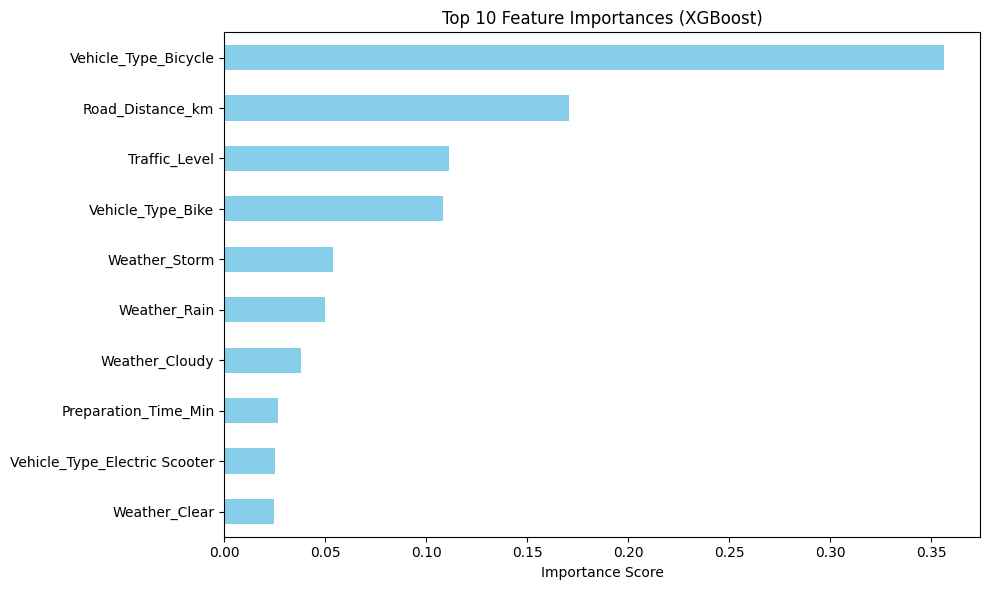

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature names from the OneHotEncoder step
ohe_cols = (
    xgb.named_steps["preprocessor"]
    .named_transformers_["nominal"]
    .named_steps["scalar"]
    .get_feature_names_out(nominal_col)
)

# Combine all processed feature names in order
all_feature_names = list(num_cols) + list(ohe_cols) + list(ordinal_col)

# Extract XGBoost feature importances
importances = xgb.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=True)

# Plot top 10 features
plt.figure(figsize=(10, 6))
feat_imp.tail(10).plot(kind="barh", color="skyblue")
plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

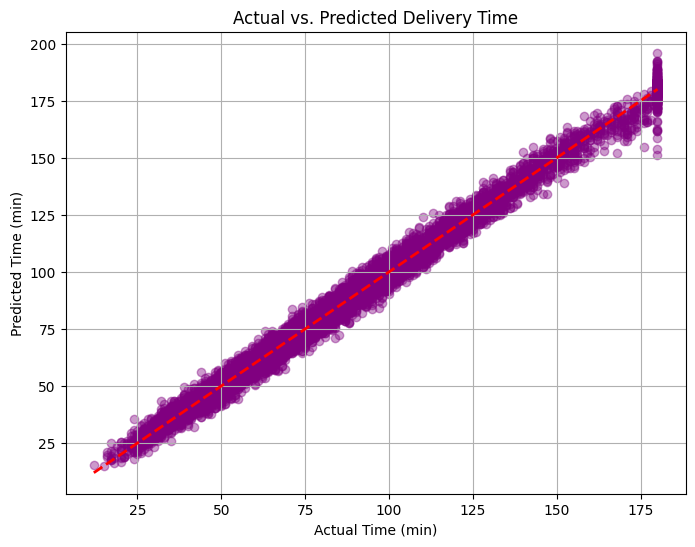

In [19]:
# Plot Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Time (min)")
plt.ylabel("Predicted Time (min)")
plt.title("Actual vs. Predicted Delivery Time")
plt.grid(True)
plt.show()

In [20]:
import joblib

# Save the complete pipeline
joblib.dump(xgb, 'xgb_delivery_time_model.pkl')
print("Model pipeline saved successfully!")

Model pipeline saved successfully!
